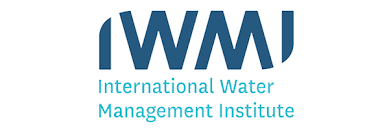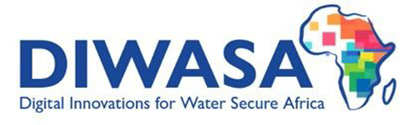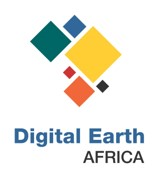
# **Lake Volume Monitoring Tool**  

 **Products used:**
[ls5_sr](https://explorer.digitalearth.africa/ls5_sr),
[ls7_sr](https://explorer.digitalearth.africa/ls7_sr),
[ls8_sr](https://explorer.digitalearth.africa/ls8_sr)

## Background
Managing water sustainably means balancing what lakes and reservoirs can supply against demand from different sectors, which makes regular, accurate monitoring of storage changes essential for fair water allocation, protecting ecosystems, and understanding climate and land-use impacts.
Lake and reservoir volume depends on the balance between inflows (rainfall, rivers, and industrial discharge) and outflows (evaporation, seepage, withdrawals, and river discharge). This has traditionally been tracked with in-situ gauging stations, but many lakes, especially in developing countries, remain ungauged, and even where data exists, it's often not shared openly between agencies, complicating coordinated management. Estimating lake volume also normally requires combining water-level data with detailed bathymetric and topographic surveys, which are expensive and time-consuming to collect, further limiting assessments.
Satellite altimetry, combined with imagery like Landsat and Sentinel, offers a practical alternative for monitoring lake volume where ground data is scarce or inaccessible. This use case applies that approach to Lake Ziway in Ethiopia's Central Rift Valley, using satellite imagery and altimetry from 1992–2023 to build a tool that supports continuous monitoring, informs understanding of climate change impacts, and promotes sustainable water management.


## Surface reflectance product

The United States Geological Survey's (USGS) [Landsat satellite program](https://www.nasa.gov/mission_pages/landsat/overview/index.html) has been capturing images of the African continent for more than 30 years. These data are highly useful for land and coastal mapping studies.

DE Africa's Landsat data is ingested from the [USGS Collection 2, Level 2](https://www.usgs.gov/land-resources/nli/landsat/landsat-collection-2?qt-science_support_page_related_con=1#qt-science_support_page_related_con) archive and forms a single, cohesive Analysis Ready Data (ARD) package, which allows you to analyse surface reflectance data as-is without the need to apply additional corrections.

## Description
**Lake Water Level product**

Lake water level data is derived by combining two altimetry sources: G-REALM and DAHITI.


 1. G-REALM
https://ipad.fas.usda.gov/cropexplorer/global_reservoir/gr_regional_chart.aspx?regionid=eafrica&reservoir_name=Ziway&lakeid=000349
2. DAHITI
https://dahiti.dgfi.tum.de/en/api/doc/v2/download-water-level/

This notebook is designed to monitor and analyze the variations in lake volume over time using satellite imagery (Landsat) and altimetric lake level data. **The primary goal is to provide a comprehensive workflow for estimating lake volume changes, which is crucial for understanding hydrological dynamics, water resource management, and environmental monitoring.**

Key steps:

1.	**Define the AOI**: Set the lake's geographic extent via bounding box or shapefile.
2.	**Load Landsat imagery**: Use load_ard() to retrieve a cloud-masked, merged Landsat 5/7/8 time series for the AOI.
3.	**Load altimetric data**: Retrieve lake water-level records and merge with Landsat dates closest in time.
4.	**Align datasets**: Temporally synchronize imagery and altimetry.
5.	**Extract lake area**: Apply a water index (e.g., MNDWI) to Landsat imagery to derive surface area over time.
6.	**Fit a regression model**: Relate lake area to lake level to enable volume estimation.
7.	**Estimate volume variation**: Combine area and level data using the fitted model.
8.	**Visualize and export**: Generate time-series plots/maps, save results for sharing or further analysis, and interpret trends and their likely causes.

**Key expected outputs**:

•	Time series of Landsat-derived lake surface area

•	Regression equation relating lake level to surface area

•	Time series of estimated lake volume variation relative to a datum


## Getting started

To run this analysis, run all the cells in the notebook, starting with the "Load packages" cell.

# Load Package

The notebook starts by importing several libraries essential for data handling, visualization, and analysis, including datacube, geopandas, matplotlib, numpy, pandas, and others related to remote sensing and geospatial analysis. Running this code cell initializes your working environment by loading specialized packages into memory. Without loading these libraries, Python will not recognize geospatial data structures or mathematical routines. Executing this setup cell prepares your notebook specifically for the lake volume monitoring exercise by ensuring all tools for handling raster data, time-series alignment, and plotting are active. 

In [1]:
%matplotlib inline

In this step, install the extra Python packages that the DE Africa Sandbox does not ship with by default but which this workflow needs for querying STAC catalogues, parallel processing with Dask, and handling vector/raster geospatial data.

**Key functions:** `pip install` (installs `pystac-client`, `stackstac`, `dask[distributed]`, `geopandas`, `shapely`, `rioxarray`, `rasterio`, `folium`, `s3fs`).

In [2]:
# pip -q install pystac-client stackstac dask[distributed] geopandas shapely rioxarray rasterio folium s3fs

### Data handling Packages

Load the core scientific and geospatial Python libraries that underpin the whole workflow — array handling, tabular data, multi-dimensional raster data, and connecting to the DE Africa datacube.

**Key functions:** `numpy`, `pandas`, `xarray`, `rioxarray`, `datacube.Datacube`, `datacube.utils.geometry.Geometry`, `datetime.timedelta`.

In [3]:
import os
os.environ["USE_PYGEOS"] = "0"
import datacube
import numpy as np
import pandas as pd
import geopandas as gpd

### Geospatial Analysis Packages

Bring in the geospatial libraries used to define your study area, connect to cloud-hosted satellite data on AWS, and calculate water indices later in the notebook. Geospatial analysis packages help you work with location-based data, define the study area, and prepare these datasets for analysis. In this exercise, the following geospatial analysis packages are used:

**Key functions:** `shapely.geometry.shape()`, `geopandas`, `configure_s3_access()`, `define_area()`, `load_ard()`, `xr_rasterize()`, `create_local_dask_cluster()`, `calculate_indices()`.

In [4]:
from odc.geo.geom import Geometry
from deafrica_tools.areaofinterest import define_area  # Defines the area of interest for analysis
from deafrica_tools.dask import create_local_dask_cluster  # Creates a local Dask cluster for parallel computing
from deafrica_tools.bandindices import calculate_indices  # Calculates various spectral indices

### Visualization packages

To help you visually inspect and communicate your findings, we will use specialized plotting libraries. 

**Key functions:** `matplotlib.pyplot`, `seaborn`, `display_map()`, `rgb()`, `xr_animation()`, `ListedColormap`, `Patch`, `image_aspect()`.

In [5]:
# import random
import matplotlib.pyplot as plt  # Used for creating static, animated, and interactive visualizations
from deafrica_tools.plotting import display_map # Provides functions for visualizing data

### Machine Learning and Statistical Packages

Load the statistical and machine-learning packages that will later be used to build and evaluate the polynomial regression linking lake area to lake level.

**Key functions:** `cv2`, `statsmodels.api.OLS`, `scipy.interpolate.griddata()`, `sklearn.linear_model.LinearRegression`, `sklearn.metrics.mean_squared_error()`, `sklearn.metrics.r2_score()`, `sklearn.preprocessing.PolynomialFeatures`.

In [36]:
# import cv2  # OpenCV library for image processing tasks
import statsmodels.api as sm  # Import statsmodels for statistical modeling and confidence intervals
from sklearn.metrics import mean_squared_error, r2_score  # Import performance metrics for model evaluation

### Custom and Supporting Python Modules for Lake Volume Monitoring

This section introduces the main Python utility modules used to support the lake-volume analysis workflow in the training notebook. These modules help organize repetitive tasks, simplify image-processing steps, and make the analysis easier to run and reproduce. They are especially useful during training because they allow participants to focus on the workflow logic while using predefined functions for common processing tasks.

**Key functions:** `create_landsat_query()`, `Plot_L7_Before_and_After_filling()`, `plot_mndwi_slice()`, `calculate_water_area_otsu()`, `calculate_RLL()`, `calculate_rll_from_area()`, `merge_and_process_height_data()`, `plot_Annual()`.

In [7]:
from lake_volume_utils import (
    plot_band,
    plot_mndwi_slices,
    calculate_water_area_otsu,
    calculate_rll,
    calculate_rll_from_area,
    merge_and_process_height_data,
    plot_annual_lake_metrics,
    plot_gap_filling_comparison,
    load_process_satellite_data,
    plot_first_last_mndwi,
    calculate_and_plot_water_area,
)

## Set up a Dask cluster

Dask helps manage memory more effectively and speeds up analysis by running tasks in parallel. In this training, you will use Dask to process large geospatial datasets without overloading your computer. To use Dask, run the code cell below to set up the local computing cluster before continuing with the analysis.

**Key functions:** `create_local_dask_cluster()`.

In [8]:
create_local_dask_cluster()

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/nanaboamah89@gmail.com/proxy/8787/status,
Dashboard: /user/nanaboamah89@gmail.com/proxy/8787/status,Workers: 1
Total threads: 4,Total memory: 26.21 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:43159,Workers: 0
Dashboard: /user/nanaboamah89@gmail.com/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:42293,Total threads: 4
Dashboard: /user/nanaboamah89@gmail.com/proxy/42617/status,Memory: 26.21 GiB
Nanny: tcp://127.0.0.1:38583,


# Connect to the datacube

Before accessing the datasets stored in the DE Africa data repository, you first need to connect the notebook to the datacube. Run the code cell below to establish this connection. In the code, set the app parameter to a unique name that clearly identifies this notebook; this makes it easier to identify and manage this analysis session separately from other notebook sessions. 

In [9]:
dc = datacube.Datacube(app="Lake_Volume_monitoring_Tool")

Before loading or analyzing satellite data, you need to define the area of interest for this exercise. In this notebook, the define_area() function from the deafrica_tools package is used to set the geographic boundary around Lake Ziway using a central latitude and longitude, together with small latitude and longitude buffers. This creates a geospatial polygon that will be used to clip datasets so the analysis focuses only on the Lake Ziway study area.

Run the code cell below to define the region of interest using `define_area(lat=7.999, lon=38.843, lat_buffer=0.160, lon_buffer=0.141)`

**Key functions:** `define_area()`.

In [10]:
# Define AOI using deafrica_tools
aoi = define_area(lat=7.999, lon=38.843, lat_buffer=0.160, lon_buffer=0.141)

Next, the notebook converts the AOI into a format that Python can use for mapping and spatial analysis. It then checks that the boundary is valid and identifies the outer coordinate limits of the study area: the minimum and maximum longitude and latitude values. These limits help the notebook load only the satellite images needed for Lake Ziway, clip the data to the correct area, and avoid spatial errors before continuing with the analysis. Run the code cell below to create the geopolygon for the study area.

**Key functions:** `shapely.geometry.shape()`, `geopandas.GeoDataFrame()`, `.total_bounds`.

In [11]:
##Create a geopolygon and geodataframe of the area of interest
geopolygon = Geometry(aoi["features"][0]["geometry"], crs="epsg:4326")
geopolygon_gdf = gpd.GeoDataFrame(geometry=[geopolygon], crs=geopolygon.crs)

# Get the latitude and longitude range of the geopolygon
lat_range = (geopolygon_gdf.total_bounds[1], geopolygon_gdf.total_bounds[3])
lon_range = (geopolygon_gdf.total_bounds[0], geopolygon_gdf.total_bounds[2])

# Print the ranges
print("Latitude Range:", lat_range)
print("Longitude Range:", lon_range)

Latitude Range: (np.float64(7.839), np.float64(8.159))
Longitude Range: (np.float64(38.702), np.float64(38.984))


# View the area of Interest on an interactive map
The next cell will display the selected area on an interactive map. The red border represents the area of interest of the study. Zoom in and out to get a better understanding of the area of interest. Clicking anywhere on the map will reveal the latitude and longitude coordinates of the clicked point.

In [12]:
display_map(lon_range, lat_range)

# Load the Water level CSV Data and creat a list of dates

The primary purpose of this notebook is to establish a relationship between lake level data, obtained from an altimetric database, and lake area, derived from Landsat images. To achieve this goal, it is essential to select Landsat images that correspond to the exact date or the nearest date of the altimetric data acquisition. Therefore, loading the lake level data and creating a list of dates is a critical first step, as this list will be used to select the appropriate Landsat images for each respective date.

To begin, the code utilizes the pandas library to read the lake level data from a CSV file named Alt_Height_COMB.csv. The parse_dates parameter is employed to convert the "Date" column into datetime objects, which facilitates easier manipulation.

>N.B. Alt_Height_COMB.csv is the combined lake level data from GRLM (https://ipad.fas.usda.gov/cropexplorer/global_reservoir/) and DAHIT (https://dahiti.dgfi.tum.de/en/products/water-level-altimetry/) altimetric satellite products.

Then it filters the data to create a list of dates, referred to as Date_list. This list is generated by selecting rows from the DataFrame where the "Date" falls within the specified range from 1992 to 2024, using boolean indexing for precise selection.

After filtering, it extracts the "Date" column and converts it into a list of date objects. To ensure the list is sorted and contains only unique dates, the code applies Python's set function to remove duplicates and then sorts the remaining dates in ascending order.

By completing these steps, the code effectively prepares a clean, sorted list of unique dates from the lake height data, which is essential for the subsequent analysis involving Landsat images.

**Key functions:** `pandas.read_csv()`, boolean date filtering, `sorted()`, `set()`.

In [13]:
# load the altimetric lake height data
# Lake_level = "Data/Alt_Height_COMB.csv"
lake_level_data = pd.read_csv("Alt_Height_COMB.csv", parse_dates=["Date"])

# Create a list of dates (Date_list) from the lake level data
Date_list = lake_level_data[
    (lake_level_data["Date"] >= "1992") & (lake_level_data["Date"] <= "2024")
]
Date_list = Date_list["Date"].dt.date.tolist()

# Ensure the Date_list is sorted and contains unique dates
Date_list = sorted(set(Date_list))

In [14]:
(
    ds_raw,
    ds_filtered_raw,
    ds_processed,
    filtered_result,
    available_dates,
    filtered_dates,
    interpolated_dates,
    gap_statistics,
) = load_process_satellite_data(
    dc=dc,
    geopolygon_gdf=geopolygon_gdf,
    # Load all Landsat missions together
    products=["ls5_sr", "ls7_sr", "ls8_sr"],
    # Complete date range
    time=("1992-01-01", "2024-12-31"),
    measurements=["green", "swir_1"],
    # Fill across columns
    interpolation_dim="y",
    interpolation_method="linear",
)

Automatically generated product periods:
  ls5_sr     1992-01-01 to 1999-12-31
  ls7_sr     2000-01-01 to 2013-12-31
  ls8_sr     2014-01-01 to 2024-12-31

[1/3] Loading ls5_sr
Period: 1992-01-01 to 1999-12-31
Using pixel quality parameters for USGS Collection 2
Finding datasets
    ls5_sr


/opt/venv/lib/python3.12/site-packages/deafrica_tools/datahandling.py:245: UserWarning: Setting 'min_gooddata' percentage to > 0.0 will cause dask arrays to compute when loading pixel-quality data to calculate 'good pixel' percentage. This can slow the return of your dataset.
  warnings.warn(


Counting good quality pixels for each time step
Filtering to 52 out of 149 time steps with at least 95.0% good quality pixels
Applying pixel quality/cloud mask
Re-scaling Landsat C2 data
Returning 52 time steps as a dask array
Observations loaded: 52
ls5_sr completed in 44.0s

[2/3] Loading ls7_sr
Period: 2000-01-01 to 2013-12-31
Using pixel quality parameters for USGS Collection 2
Finding datasets
    ls7_sr


/opt/venv/lib/python3.12/site-packages/deafrica_tools/datahandling.py:565: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge([ds_data, ds_masks])
/opt/venv/lib/python3.12/site-packages/deafrica_tools/datahandling.py:245: UserWarning: Setting 'min_gooddata' percentage to > 0.0 will cause dask arrays to compute when loading pixel-quality data to calculate 'good pixel' percentage. This can slow the return of your dataset.
  warnings.warn(


Counting good quality pixels for each time step
Filtering to 103 out of 193 time steps with at least 95.0% good quality pixels
Applying pixel quality/cloud mask
Re-scaling Landsat C2 data
Returning 103 time steps as a dask array
Observations loaded: 103
Checking Landsat 7 images for missing scan-line pixels...


...

Images selected for interpolation: 95
ls7_sr completed in 2m 18s

[3/3] Loading ls8_sr
Period: 2014-01-01 to 2024-12-31
Using pixel quality parameters for USGS Collection 2
Finding datasets
    ls8_sr


/opt/venv/lib/python3.12/site-packages/deafrica_tools/datahandling.py:245: UserWarning: Setting 'min_gooddata' percentage to > 0.0 will cause dask arrays to compute when loading pixel-quality data to calculate 'good pixel' percentage. This can slow the return of your dataset.
  warnings.warn(


Counting good quality pixels for each time step
Filtering to 101 out of 240 time steps with at least 95.0% good quality pixels
Applying pixel quality/cloud mask
Re-scaling Landsat C2 data
Returning 101 time steps as a dask array
Observations loaded: 101
ls8_sr completed in 1m 12s

Merging Landsat collections...


/opt/venv/lib/python3.12/site-packages/deafrica_tools/datahandling.py:565: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge([ds_data, ds_masks])



PROCESSING COMPLETE
Merged observations: 256
Filtered observations: 256
Interpolated Landsat 7 dates: 95
Total runtime: 4m 14s


### Analysis Time, Query Parameters

Using the start and end dates, we will Set time range for different Landsat satellite missions that we want for our application. The analysis period began in 1992, as the satellite altimetry lake level data for Ziway lake recoded began in 1992. As a result, computations of lake water extent (area) using imagery from satellites or landsat data began in 1992.

The Query dictionar was also set in this section through the create_landsat_query(), which prepares query dictionaries for retrieving Landsat satellite images. Each dictionary specifies parameters such as geographic bounds, resolution, and time range for three different Landsat missions.

Each section of the code plays a crucial role in preparing for analysis, from setting up the environment and defining the area of study to loading and querying the necessary data.

#### Justifications of analysis parameters used in these query are Explained below:
**geopolygon_gdf.total_bounds**: This property provides the bounding box coordinates of the geospatial polygon defined by geopolygon_gdf. It returns an array where:

    total_bounds[0]: Minimum x-coordinate (longitude).
    total_bounds[1]: Minimum y-coordinate (latitude).
    total_bounds[2]: Maximum x-coordinate (longitude).
    total_bounds[3]: Maximum y-coordinate (latitude).
**+ 0.01**: The addition of 0.01 to each coordinate is intended to create a small buffer around the geopolygon's bounding box. This can help ensure that the query captures all relevant imagery, especially if the data retrieval process uses strict bounding coordinates.

**resolution: (-30, 30)**: This parameter defines the desired spatial resolution of the Landsat images in meters. The negative value indicates the resolution for the x-axis (east) and the positive value for the y-axis (north). Landsat imagery typically has a resolution of 30 meters, making this setting appropriate.

**output_crs: "EPSG:6933"**: This specifies the coordinate reference system to which the output data will be transformed. EPSG:6933 is an equal-area projection, which is beneficial for global datasets as it preserves area proportions, making it suitable for analysis that involves spatial relationships.

**group_by: "solar_day"**: This groups the retrieved images by solar day, helping to manage datasets with multiple images taken on the same day. This is useful for reducing redundancy and simplifying subsequent analysis.
**time: (start_date, end_date)**: This parameter defines the time range for the query. It restricts the data retrieval to only those Landsat images that fall within the specified start and end dates, ensuring that the analysis focuses on the relevant temporal data.


**What you'll learn:** How to set the analysis time windows for each Landsat mission (5, 7, and 8) and build the query dictionaries — containing the AOI, resolution, and date range — that `load_ard()` needs to retrieve imagery for each satellite.

**Key functions:** `create_landsat_query()`.

## Load Landsat images
load a collection of Landsat images while applying specific criteria for data quality and chunk management.
This is particularly useful in remote sensing applications where large datasets need to be processed efficiently.
Important components in loading the Landsat are:

**Setting Chunk Size:**
The variable dask_chunks is defined as a dictionary with keys x and y, both set to 500. This configuration specifies how the image data will be divided into manageable chunks for processing. Utilizing Dask allows for parallel processing, improving performance when working with large datasets.

**Cloud-Free Data Threshold:**
The variable cloud_free is set to 0.95, indicating that the code aims to load images with at least 95% of the pixels classified as good data (i.e., not obscured by clouds). This is crucial for ensuring the quality of the images used in analysis.


📝 In this step, you will learn how to configure two parameters that control how the Landsat data will be loaded: the Dask chunk size (for efficient parallel processing) and the minimum acceptable proportion of cloud-free pixels per scene.

**Key functions:** `dict()` (chunk size definition).

**Loading using load_ard():**

The load_ard function is used to load the analysis-ready images in which we usually don't need further image enhancement

**Key functions:** `load_ard()`.

📝 Retrieve the equivalent Landsat 7 image collection for the same bands and AOI, which will still contain the striping artefact from the Scan Line Corrector failure that is corrected in the next steps.

📝 Retrieve the Landsat 8 image collection, completing the three-satellite time series (1992–2024) that will be merged into a single dataset.

## Fill the horizontal stripe in Landsat 7 image

We can address the issue of missing values in Landsat 7 datasets caused by the Scan Line Corrector (SLC) failure. We employs interpolation techniques to fill in the horizontal stripe artifacts in the images, ensuring that the data can be used for further analysis without significant gaps. The process is described as follows

**Key functions:** `.sortby()`, `.chunk()`, `.interpolate_na()`.

### Visualize the filling gap process

Visually check that the gap-filling worked by picking a random Landsat 7 scene from 2004 onward and plotting it side-by-side before and after interpolation.

In [15]:
# plot_band(ds=ds_landsat_raw, start_date="2004")
# plot_band(ds=ds_landsat_filled, ds_after=ds_landsat_filled, start_date="2004")

## Merge the Landsat image collections (ls5,ls7 &ls8) in one datasets

Note that in the Load image stage, each Landsat image product—Landsat 5, filled Landsat 7, and Landsat 8—was loaded separately. However, to facilitate comprehensive analysis and processing, these collections need to be merged into a single dataset called ds_landsat. The merging process starts with combining the filled Landsat 7 dataset (ds_L7_filled) with the Landsat 5 dataset (ds_L5), followed by the addition of the Landsat 8 dataset (ds_L8). This code below checks if the datasets are defined and not None, then merges them into one dataset along the time dimension. If successful, it displays the merged dataset; otherwise, it informs you that no datasets are available to merge. Let me know if you need any specific changes or explanations!

**Key functions:** `xarray.concat()`, `.sortby()`.

The next step extracts all time values from a Landsat dataset, converts them into a clean and readable date format, optionally reformats them into strings, and writes them to a text file. This is particularly useful for quality checking, debugging, reporting available imagery dates, or preparing metadata for further analysis.

**Key functions:** `pandas.to_datetime()`. `.strftime()`. `open()`, file write with a `for` loop.

# Select the images for the dates close to that of Altimetric data

After merging all the datasets, the next step is to select Landsat images that correspond closely to the dates of altimetric (lake level) data. Expanding the date list is crucial because the number of available Landsat images for the exact dates when lake level data were recorded is often very limited, making it unreliable for building any statistical relationship. By extending the date range to include dates within ±3 days of each recorded lake level observation, the code ensures a more significant number of Landsat images are available for analysis. This approach is vital for accurately calculating lake area and establishing meaningful relationships with the lake level data.

The process begins by creating a set called expanded_dates, which includes all dates from Date_list along with additional dates spanning a three-day range before and after each date. The expanded dates are then sorted and formatted to match the available dates in the Landsat dataset. The code filters this list to retain only those dates that exist in available_dates. The time coordinate of the ds_landsat dataset is also formatted to ‘yyyy-mm-dd’.

Subsequently, the dataset is filtered to include only the images from the selected filtered_dates. This filtered dataset is converted to a DataArray, retaining all measurements for further analysis. Finally, the code prints a confirmation message along with the resulting DataArray and the list of filtered dates for inspection.

**Key functions:** `timedelta()`, `set()`, `.sel()`, `.to_array()`.

## Computing Modified Normalized Difference Water Index (MNDWI)

The Modified Normalized Difference Water Index (MNDWI) is a remote sensing index designed to enhance the presence of water bodies in satellite imagery. It is particularly useful for distinguishing water from other land cover types, making it an essential tool for monitoring water resources, assessing flood extents, and studying changes in lake levels. The MNDWI is calculated using the following equation:

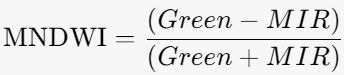

where:

* Green: refers to the reflectance in the green band.
* MIR: refers to the reflectance in the mid-infrared band (Swir_1).

The code we used to calculate the MNDWI is a DEAfrica calculate_indices package.

The process begins by defining the input data, data_array, which focuses on the area of interest. If this input is a DataArray, it is converted to a Dataset to ensure compatibility. The MNDWI is then computed using a custom function called calculate_indices, specifying the Landsat satellite mission. After the calculation, the code selects only the MNDWI variable from the resulting dataset, discarding other bands.

The MNDWI values are plotted in a layout organized into multiple columns based on time, using a colormap that highlights water features. A title is added to the figure, and the plot is saved as a PNG file in a specified directory. Finally, the plot is displayed on the screen, and the figure is closed to free up resources.

Compute the Modified Normalized Difference Water Index (MNDWI) for every scene in the filtered time series, the spectral index used to separate water from land in each Landsat image.

**Key functions:** `.to_dataset()`, `calculate_indices()`.

In [16]:
# Now calculate the indices
from deafrica_tools.bandindices import calculate_indices  # Calculates various spectral indices
mndwi = calculate_indices(ds=filtered_result, index="MNDWI", satellite_mission="ls")

In [17]:
mndwi = mndwi["MNDWI"]  # selecting only the MNDWI variable, and dropping other bands

### MNDWI Map plot for Visualization


#### Plot few selected Time-step MNDWI images

In this plot, we will visualize the MNDWI across several key time steps. Instead of plotting all time-steps simultaneously, which can lead to a cluttered and overwhelming display, we will select a few representative slices from the start and end of the time-steps to visualize the computed indices.

Visually inspect the MNDWI results across time by plotting the first 20 and last 20 time-steps, rather than every scene at once, so you can spot obvious water/land patterns and data quality issues at the start and end of the record.

**Key functions:** `.isel()`, `plot_mndwi_slice()`.

Selected 20 of 256 observations.
Display resolution reduced by a factor of 4 along each spatial dimension.
Loading selected MNDWI images for plotting...


/opt/venv/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 11.37 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Selected images loaded successfully.


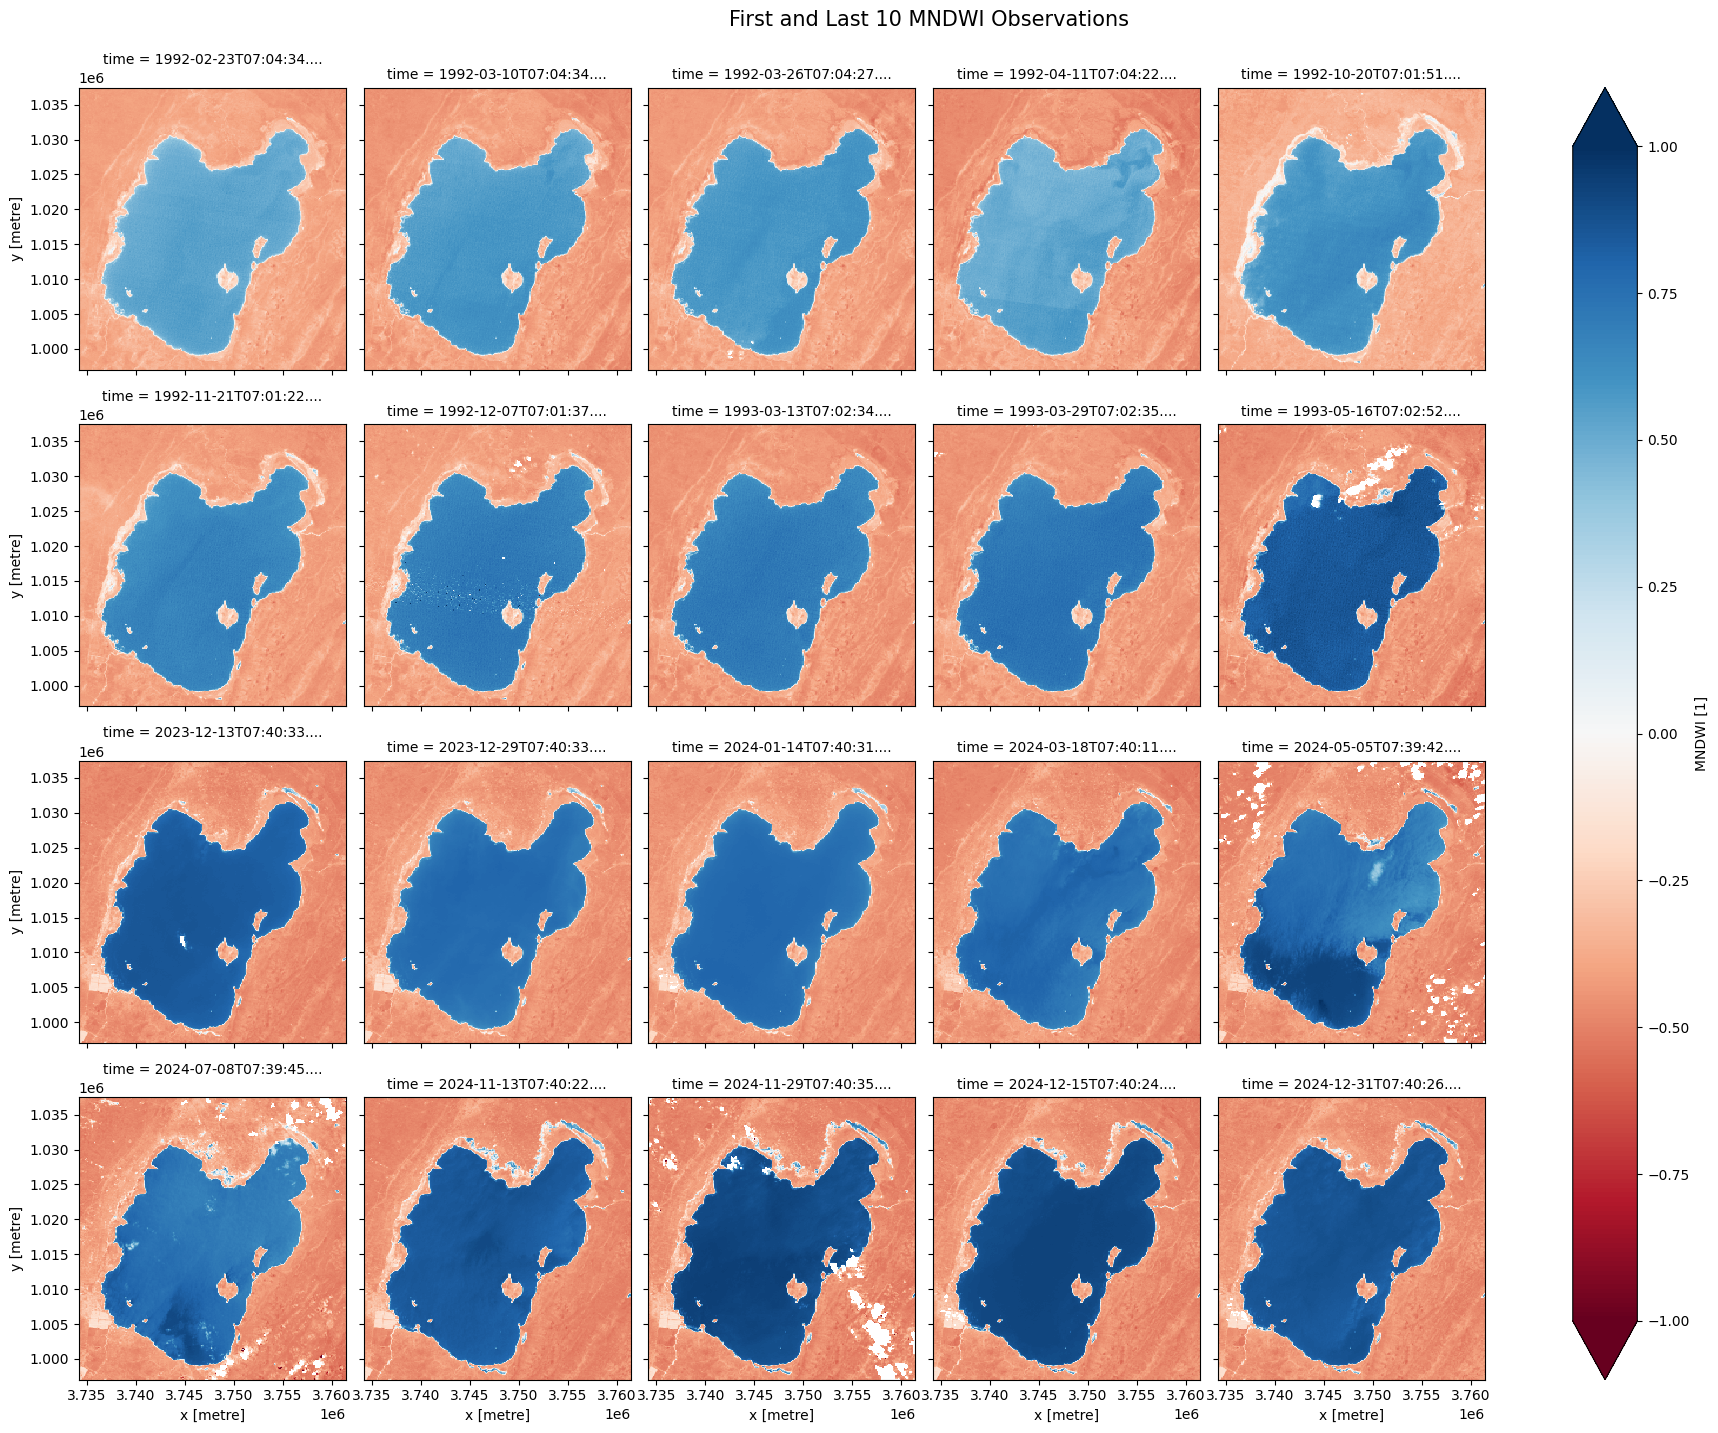

In [18]:
mndwi_display = plot_first_last_mndwi(
    mndwi,
    number_of_slices=10,
    display_reduction=4,
    col_wrap=5,
)

# Area calculation using Automatic water extraction

This method (Method 1) used zero Thresholod of MNDWI for Water body Extraction

Setting a threshold value to discriminate between water bodies and non-water areas is a crucial and often challenging task in remote sensing. The choice of threshold can significantly impact the accuracy of water area calculations. In this code snippet, a default threshold value of zero is used; pixels with a Modified Normalized Difference Water Index (MNDWI) greater than zero are classified as water. This approach simplifies the classification, but it is essential to understand that different environments may require adjustments to this threshold for optimal results.

The code begins by determining the pixel resolution in meters, which is necessary for calculating the area represented by each pixel. The area per pixel is computed by squaring the pixel length and converting it to square kilometers.

**Key functions:** basic arithmetic operations on the `resolution` value stored in the query dictionary.

Next, the code identifies pixels classified as water using the MNDWI threshold. Pixels with MNDWI values greater than zero are retained, while others are replaced with NaN values. The valid water pixels are counted, and their total area is obtained by summing the values across the spatial dimensions (x and y).

Classify each pixel as "water" or "not water" using a simple MNDWI > 0 threshold (Method 1), then sum the water pixels per time-step and convert the count into a surface-area time series (`ds_valid_water_area`).

**Key functions:** `.where()`, `numpy.isnan()`, `.sum()`.

Pixel area: 0.000900 km²
Calculating water area for 256 observations...


/opt/venv/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 11.41 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


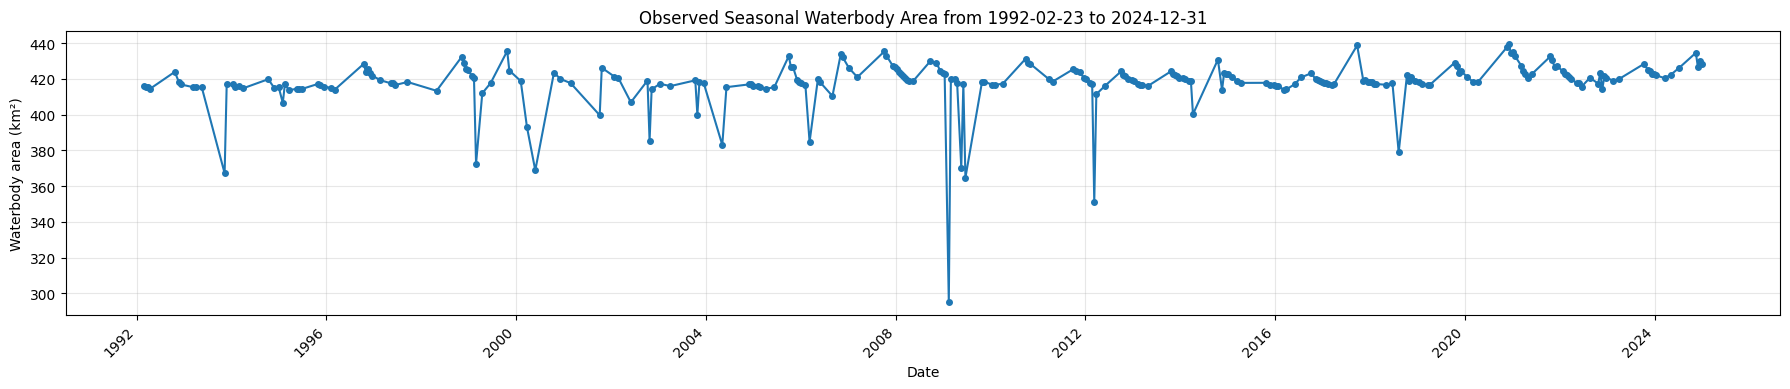


Water-area calculation completed.
Observations: 256
PNG saved to: results/Area_awi_3dd.png
CSV saved to: results/Area_awi_3dd.csv
Runtime: 319.5 seconds


In [19]:
ds_valid_water_area, water_area_df = (
    calculate_and_plot_water_area(
        mndwi=mndwi,
        threshold=0.0,
        pixel_length_m=30,
        output_folder="results",
        filename="Area_awi_3dd",
        compute=True,
    )
)

In the above code cell, we used a function of `mndwi.where, np.isnan, df.reset_index`.

`mndwi.where(mndwi > 0, np.nan)` is used to create a mask that identifies water pixels based on the MNDWI. Pixels where MNDWI is greater than 0 are classified as water, while others are set to NaN. This is crucial for isolating water bodies in satellite imagery, enabling further analysis or calculations related to water area.
The function `np.isnan(water)`checks for NaN values in the water array. In this case, it is used to create a mask for the subsequent operation water.where(np.isnan(water), 1), which effectively counts the number of pixels that are classified as water (i.e., those that are not NaN). This helps in quantifying the extent of water bodies in the analysis.


*Check and convert Time Coordinate for Data Integrity:*
To prepare the data for plotting, the time coordinate is converted to a datetime format, and the code checks for any NaN values in the dataset. If any NaNs are found, a warning is printed. Finally, a plot of the observed seasonal water area over time is created, complete with labels and gridlines for clarity. The plot is displayed and saved as a PNG file for future reference.

**Key functions:** `pandas.to_datetime()`, `.isnull()`.

#### Plotting Lake area timeseries

Produce a time-series plot of Lake Ziway's observed surface water area across the full Landsat record, giving you a first look at how the lake's extent has changed over the decades.

**Key functions:** `plt.figure()`, `plt.plot()`, `plt.savefig()`, `plt.show()`.

### Save Water surface Area in csv file

Convert the water-area results from an xarray object into a tabular pandas DataFrame and export them to CSV, so the area time series can be reused in the regression analysis later in the notebook.

**Key functions:** `.to_dataframe()`, `.reset_index()`, `.rename()`, `.to_csv()`.

# Prepare Area and Water level data for regression analysis

Reload the altimetric lake-level data and the Landsat-derived water-area CSV you just saved, bringing both datasets into memory ready to be combined.
**Key functions:** `pandas.read_csv()`.

In [20]:
# Load and/or re-assign once again to the Lake level and area datasets
alt_height = pd.read_csv('Alt_Height_COMB.csv')
ziway_area = pd.read_csv('results/Area_awi_3dd.csv') # make sure which Area culculation used

Convert the date columns of both datasets into a common date format, a necessary step before the two tables can later be matched and merged.

**Key functions:** `pandas.to_datetime()`, `.dt.date`.

In [21]:
# Convert the 'Date' and 'time' columns to date format
alt_height['Date'] = pd.to_datetime(alt_height['Date'], errors='coerce').dt.date
ziway_area['time'] = pd.to_datetime(ziway_area['time'], errors='coerce').dt.date

Remove rows where the date conversion failed (producing "Not a Time" values), keeping only records with valid, usable dates.

**Key functions:** `.dropna()`.

In [22]:
# Drop rows with NaT values (from conversion errors)
alt_height = alt_height.dropna(subset=['Date'])
ziway_area = ziway_area.dropna(subset=['time'])

Clean the altimetric record by removing rows flagged with the dataset's "no data" sentinel value (9999.99 m), which would otherwise distort the analysis if left in.

**Key functions:** boolean filtering on a DataFrame column.

In [23]:
# Remove rows where Height is 9999.99
# N.B. 9999.99 represent the missing (no data) value
alt_height = alt_height[alt_height['Height'] != 9999.99]

Do a quick visual sanity-check of both cleaned datasets before merging them, confirming that the filtering steps worked as expected.

**Key functions:** `print()`.

In [24]:
print(alt_height, ziway_area)

            Date     Height
0     1992-09-26  1638.0400
2     1992-10-16  1638.3100
4     1992-11-05  1637.7400
5     1992-11-15  1637.3800
6     1992-11-25  1637.7100
...          ...        ...
1295  2024-09-19  1638.7280
1296  2024-09-29  1638.8645
1297  2024-10-09  1638.6740
1298  2024-10-19  1638.7140
1299  2024-10-29  1638.6450

[820 rows x 2 columns]            time  spatial_ref satellite_product  Water Area
0    1992-02-23         6933            ls5_sr    416.1177
1    1992-03-10         6933            ls5_sr    415.2717
2    1992-03-26         6933            ls5_sr    415.2969
3    1992-04-11         6933            ls5_sr    414.3762
4    1992-10-20         6933            ls5_sr    423.9279
..          ...          ...               ...         ...
251  2024-07-08         6933            ls8_sr    426.2319
252  2024-11-13         6933            ls8_sr    434.6010
253  2024-11-29         6933            ls8_sr    426.5532
254  2024-12-15         6933            ls8_sr    

### Remove areas from unaccepted renge 
If the some very high or very low lake area derived from the MNDWI is suspected without reasonable justification, it is taken as unacceptable and not considered for further analysis. in our analysis, in reference with studies in ziway, the area below 400 and above 500 sq.km is considered unacceptable and removed.

Apply a plausibility filter to the derived lake area, discarding Landsat-derived area estimates outside a realistic range (400–500 km²) for Lake Ziway, since values far outside this range likely reflect cloud contamination or extraction errors rather than real lake changes.

**Key functions:** boolean filtering on a DataFrame column.

In [25]:
# Remove rows with Lake_area values greater than 500 sq.km
ziway_area = ziway_area[ziway_area['Water Area'] <= 500]
# Remove rows with Lake_area values greater than 500 sq.km
ziway_area = ziway_area[ziway_area['Water Area'] >= 400]

Match each Landsat-derived area observation to the nearest altimetric water-level readings within a 3-day window, creating a shared `time` column that both datasets can later be merged on.

**Key functions:** `pandas.Timestamp()`, `pandas.Timedelta()`, `.iterrows()`, boolean date-range filtering.

In [26]:
# Create a new column for Lake water level dataset "Alt_Height.csv" called "time" 
#as the same column name to Lake Area dataset, used for merging the two dataset

# Initialize the new time column
alt_height['time'] = pd.NaT

# For each date in the 'time' column of ziway_area, find all dates in alt_height within 
# a three-day delta
for i, lake_row in ziway_area.iterrows():
    # Create a date range for the three-day delta
    start_date = pd.Timestamp(lake_row['time']) - pd.Timedelta(days=3)
    end_date = pd.Timestamp(lake_row['time']) + pd.Timedelta(days=3)

    # Ensure alt_height['Date'] is of type Timestamp for comparison
    valid_dates = alt_height[(pd.to_datetime(alt_height['Date']) >= start_date) & 
                              (pd.to_datetime(alt_height['Date']) <= end_date)]

    if not valid_dates.empty:
        # Convert lake_row['time'] to a string in date format (YYYY-MM-DD) for all matching dates
        alt_height.loc[valid_dates.index, 'time'] = lake_row['time'].strftime('%Y-%m-%d')

Save the intermediate, date-matched altimetric table to CSV, giving you a checkpoint you can inspect or reuse without repeating the matching step above.

**Key functions:** `.to_csv()`.

In [27]:
# save the lake level data to new file and check the how the date was lake level dates was
#substitute with the respective lake area dates with the required closest date range
alt_height.to_csv('alt_height2.csv',index=False) 

Make sure the shared `time` column in both the area and altimetric tables is stored as a proper datetime type, which is required for an exact match during the merge step that follows.

**Key functions:** `pandas.to_datetime()`.

In [28]:
# Ensure 'time' in both DataFrames is of datetime type
ziway_area['time'] = pd.to_datetime(ziway_area['time'], errors='coerce')
alt_height['time'] = pd.to_datetime(alt_height['time'], errors='coerce')

Drop any remaining rows without a valid matched date and confirm the two tables are ready to merge.

**Key functions:** `.dropna()`, `print()`.

In [29]:
# Drop rows in alt_height with NaN (if any)in 'time' column and check to check dates
alt_height.dropna(subset=['time'], inplace=True)
print(alt_height), print(ziway_area)

            Date     Height       time
7     1992-12-05  1637.8400 1992-12-07
49    1994-01-25  1637.8900 1994-01-27
75    1994-10-10  1637.7800 1994-10-10
80    1994-11-29  1637.7000 1994-11-27
86    1995-01-27  1637.6700 1995-01-30
...          ...        ...        ...
1267  2023-12-16  1638.1445 2023-12-13
1268  2023-12-26  1638.0715 2023-12-29
1270  2024-01-15  1637.9705 2024-01-14
1276  2024-03-15  1637.3190 2024-03-18
1281  2024-05-03  1637.6770 2024-05-05

[133 rows x 3 columns]
          time  spatial_ref satellite_product  Water Area
0   1992-02-23         6933            ls5_sr    416.1177
1   1992-03-10         6933            ls5_sr    415.2717
2   1992-03-26         6933            ls5_sr    415.2969
3   1992-04-11         6933            ls5_sr    414.3762
4   1992-10-20         6933            ls5_sr    423.9279
..         ...          ...               ...         ...
251 2024-07-08         6933            ls8_sr    426.2319
252 2024-11-13         6933            ls8_s

(None, None)

Merge the Landsat-derived area table and the altimetric water-level table into a single dataset (`merged_data`) on their shared date, rename the columns for clarity, and save the combined table for use in the regression analysis.

**Key functions:** `pandas.merge()`, `.rename()`, `.to_csv()`.

In [30]:
# Merge the two dataframes based on the 'time' column
merged_data = pd.merge(ziway_area, alt_height, on='time', how='inner')

# Rename columns for clarity
merged_data.rename(columns={'Water Area': 'Lake_Area', 'Height': 'Lake_Level'}, inplace=True)

# Save the merged dataframe to a new CSV file
merged_data.to_csv('results/AreaHeight_awi_3dd.csv', index=False)

Review the merged area-level table, giving you your first look at the paired dataset that links lake surface area to lake water level.

In [31]:
print(merged_data)

          time  spatial_ref satellite_product  Lake_Area        Date  \
0   1992-12-07         6933            ls5_sr   416.9016  1992-12-05   
1   1994-01-27         6933            ls5_sr   415.6551  1994-01-25   
2   1994-10-10         6933            ls5_sr   419.8419  1994-10-10   
3   1994-11-27         6933            ls5_sr   414.7560  1994-11-29   
4   1995-01-30         6933            ls5_sr   406.5705  1995-01-27   
..         ...          ...               ...        ...         ...   
128 2023-12-13         6933            ls8_sr   422.7363  2023-12-16   
129 2023-12-29         6933            ls8_sr   422.5005  2023-12-26   
130 2024-01-14         6933            ls8_sr   422.0316  2024-01-15   
131 2024-03-18         6933            ls8_sr   420.3729  2024-03-15   
132 2024-05-05         6933            ls8_sr   422.4096  2024-05-03   

     Lake_Level  
0     1637.8400  
1     1637.8900  
2     1637.7800  
3     1637.7000  
4     1637.6700  
..          ...  
128   163

## Set the common Lake datum height
As this notebook's final objective is designed to calculate and monitor variations in lake volume relative to a specific datum height, setting a known or hypothetical reference datum is important. One can set the datum height either from a previously known value, such as the lowest recorded lake level, or define it as the minimum lake level within a specified time range.

In this code below, the datum height is determined using Method 2, which calculates the minimum lake level from the dataset and sets the datum height slightly lower (by 5 cm) to account for potential fluctuations. The code identifies the row corresponding to the minimum lake level, extracting relevant information such as the date, lake level, and lake area at that time.

After reporting the findings, including the datum height date, relative lake level, and lake area, the code calculates the lake depth by subtracting the datum height from the recorded lake levels, rounding the result to four decimal places. This adjustment allows for a clearer understanding of the lake's depth variations over time.


The two ways to set the lake's reference "datum" height — Method 1 uses a previously known lowest-level value supplied by the analyst (this cell is left commented out since Method 2, in the next cell, is used instead).

In [32]:
# Method 1: Define the datum height with previously known value 
#datum_height = 1636 # if this value is knowen as lowest height

Define the datum height (Method 2) as the minimum recorded lake level in the merged dataset, identify the date and lake area associated with that minimum, and convert every lake-level reading into a "Lake Depth" relative to this datum — the key variable used in the regression step that follows.

**Key functions:** `.min()`, boolean row selection, `.round()`.

In [33]:
# Method 2: Define the datum height as the minimum lake level
datum_height = merged_data['Lake_Level'].min()
datum_height2=datum_height-0.05 # 5 cm lower than the minimum 
# Get the row with the minimum lake level
datum_row = merged_data[merged_data['Lake_Level'] == datum_height]

# Extract the date, lake level, and lake area
datum_date = datum_row['time'].values[0]  # Assuming 'time' is the date column
relative_lake_level = datum_height
lake_area = datum_row['Lake_Area'].values[0]

# Report the findings
print(f"Datum Height Date: {datum_date}")
print(f"Relative Lake Level: {relative_lake_level}")
print(f"Lake Area on Datum Height Date: {lake_area}")

# Correct lake level height to lake depth
merged_data['Lake_Depth'] = (merged_data['Lake_Level'] - datum_height).round(4)

Datum Height Date: 2016-05-31T00:00:00.000000000
Relative Lake Level: 1636.365
Lake Area on Datum Height Date: 417.1122


# Polynomial Regression:

Here we implement polynomial regression to analyze the relationship between lake depth and lake area, acknowledging the complexities introduced by irregular topography. Lakes often possess varied shapes and depths due to geological formations, sedimentation, and hydrological processes. This irregularity leads to a non-linear relationship between lake area and lake level, as changes in depth do not uniformly affect the surface area. For instance, a small increase in lake depth may significantly alter the area in shallow regions, while deeper areas may exhibit less change in surface area for the same depth increment.

Given this non-linear characteristic, a second-order polynomial regression is applied in this analysis. The use of polynomial regression recognizes that as the degree of the polynomial increases, the model's capacity to capture non-linear relationships improves. In this case, a second-order polynomial allows for a more nuanced fit that can adequately represent the complexities of the lake's geometry.


#### Data Preparation:
The following code cell prepares the data for polynomial regression analysis by defining the independent variable (Lake_Depth) and the dependent variable (Lake_Area). It also generates polynomial features by adding the square of the independent variable.

Prepare the independent (Lake Depth) and dependent (Lake Area) variables for a second-order polynomial regression, by generating a squared-depth feature alongside the original depth values.

**Key functions:** `numpy.column_stack()`.

In [34]:
# Preparing data for polynomial regression analysis
X = merged_data[['Lake_Depth']]  # Independent variable (features)
y = merged_data['Lake_Area']      # Dependent variable (target)

# Generating polynomial features (up to second order)
X_poly = np.column_stack((X, X**2))  # Adding the square of the independent variable

#### Model Fitting: 
This cell fits a polynomial regression model using Ordinary Least Squares (OLS). It includes a constant term in the model to account for the intercept. It also creates a range of values for Lake_Depth to facilitate the generation of a smooth prediction line. It generates polynomial features for these values and adds a constant term.

Ordinary Least Squares (OLS) polynomial regression model relating Lake Depth to Lake Area, and how to generate a smooth range of depth values used later to draw the fitted curve.

**Key functions:** `statsmodels.api.add_constant()`, `statsmodels.api.OLS().fit()`, `numpy.linspace()`.

In [37]:
# Fitting the polynomial regression model
X_poly_with_const = sm.add_constant(X_poly)  # Include a constant term in the model
ols_model = sm.OLS(y, X_poly_with_const).fit()  # Fit the model using OLS

# Creating a range of values for Lake Depth to generate a smooth prediction line
x_range = np.linspace(X['Lake_Depth'].min(), X['Lake_Depth'].max(), 100)
x_range_poly = np.column_stack((x_range, x_range**2))  # Generating polynomial features for the range
x_range_poly_with_const = sm.add_constant(x_range_poly)  # Adding constant term

#### Model Coefficients Extraction:
This cell extracts the coefficients of the fitted polynomial regression model, including the intercept and coefficients for the linear and quadratic terms. It then prints these coefficients to provide insights into the model's structure.

Extract the fitted model's intercept and the linear and quadratic coefficients — the three numbers that define the Area–Depth relationship you will reuse throughout the rest of the notebook.

**Key functions:** `.params`, `.round()`.

In [38]:
# Extracting model coefficients
intercept = ols_model.params['const'].round(4)
coefficient_linear = ols_model.params['x1'].round(4)  # Coefficient for linear term
coefficient_quadratic = ols_model.params['x2'].round(4)  # Coefficient for quadratic term

# Outputting model coefficients
print(f'Intercept: {intercept}')
print(f'Linear Coefficient: {coefficient_linear}')
print(f'Quadratic Coefficient: {coefficient_quadratic}')

Intercept: 415.7409
Linear Coefficient: -1.3086
Quadratic Coefficient: 3.5205


#### Making Predictions:
This code cell below makes predictions using the fitted polynomial regression model. It calculates predictions for both the smooth prediction line and the original dataset, rounding the results. The predicted values are then added to the merged_data DataFrame.

Use the fitted regression model to predict Lake Area both for the smooth depth range (for plotting the curve) and for the original observed depths (for evaluating model accuracy).

**Key functions:** `.predict()`, `.round()`.

In [39]:
# Making predictions for the smooth line and rounding
smooth_predictions = (ols_model.predict(x_range_poly_with_const)).round(4)

# Calculating predictions for the original dataset and rounding
original_predictions = (ols_model.predict(X_poly_with_const)).round(4)

# Adding predicted values to the merged_data DataFrame
merged_data['Predicted_Lake_Area'] = original_predictions

Save the merged dataset—now including the model's predicted lake areas—to CSV, creating a record you can revisit without re-running the regression.

**Key functions:** `.to_csv()`.

In [40]:
# Saving the updated DataFrame to a new file
# This cell saves the updated DataFrame, which now includes the predicted lake areas, to a new CSV file for future reference or analysis.
merged_data.to_csv('results/AreaHeight_awi_3dd_pol.csv', index=False)

#### Model Performance Evaluation and Confidence Intervals:
This cell evaluates the performance of the polynomial regression model by calculating the Mean Squared Error (MSE) and R-squared score. It prints these performance metrics and calculates the 95% confidence intervals for the predictions, extracting and rounding the lower and upper bounds for further analysis.

Quantitatively assess the regression model's performance using the Mean Squared Error and R-squared score, and how to calculate 95% confidence intervals around the predictions so the uncertainty of the fit can be visualised.

**Key functions:** `mean_squared_error()`, `r2_score()`, `.get_prediction()`, `.summary_frame()`.

In [41]:
# Evaluating model performance
mse = mean_squared_error(y, original_predictions)  # Mean Squared Error
r_squared = r2_score(y, original_predictions)      # R-squared score

# Outputting performance metrics
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'R-squared: {r_squared:.4f}')

# Calculating 95% confidence intervals for the predictions
predictions_with_conf = ols_model.get_prediction(x_range_poly_with_const)
pred_summary = predictions_with_conf.summary_frame(alpha=0.05)

# Extracting confidence interval bounds and rounding
lower_bound = pred_summary['obs_ci_lower'].round(4)
upper_bound = pred_summary['obs_ci_upper'].round(4)

Mean Squared Error (MSE): 12.4760
R-squared: 0.5913


#### Plotting Polynomial Regression Results:
The code cell below visualizes the results of the second-order polynomial regression analysis between lake depth and lake area. It creates a scatter plot displaying both the actual data points (in blue) and the predicted data points (in orange). A red line represents the polynomial regression curve, while a shaded area indicates the 95% confidence interval for the predictions. The plot includes a title, axis labels, and displays the regression equation along with performance metrics (MSE and R²) in a clear format, enhancing interpretability. The legend is also included to differentiate between the actual data, predicted data, regression line, and confidence interval.

Visualise the polynomial regression results in one figure — actual vs predicted lake area, the fitted curve, the 95% confidence band, and the regression equation with its accuracy metrics annotated directly on the plot.

**Key functions:** `plt.scatter()`, `plt.plot()`, `plt.fill_between()`, `plt.text()`, `plt.savefig()`.

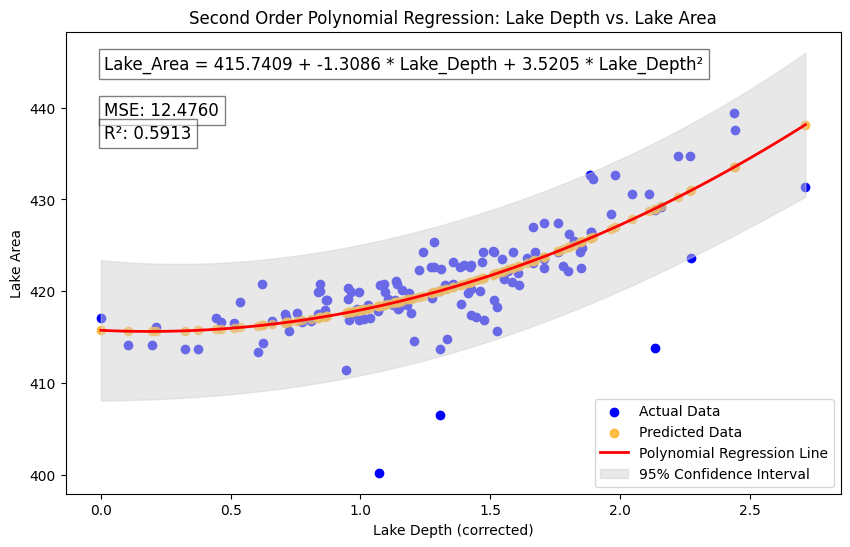

In [42]:
# Plotting the polynomial regression results
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Actual Data')  # Scatter plot of actual data
plt.scatter(X, original_predictions, color='orange', label='Predicted Data', alpha=0.7)  # Predicted data points
plt.plot(x_range, smooth_predictions, color='red', linewidth=2, label='Polynomial Regression Line')  # Polynomial regression line

# Adding confidence interval shading
plt.fill_between(x_range, lower_bound, upper_bound, color='lightgrey', alpha=0.5, label='95% Confidence Interval')

# Setting plot title and labels
plt.title('Second Order Polynomial Regression: Lake Depth vs. Lake Area')
plt.xlabel('Lake Depth (corrected)')
plt.ylabel('Lake Area')

# Displaying the regression equation on the plot
regression_equation = f'Lake_Area = {intercept:.4f} + {coefficient_linear:.4f} * Lake_Depth + {coefficient_quadratic:.4f} * Lake_Depth²'
plt.text(0.05, 0.95, regression_equation, transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))

# Adding performance metrics to the plot
plt.text(0.05, 0.85, f'MSE: {mse:.4f}', transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))
plt.text(0.05, 0.80, f'R²: {r_squared:.4f}', transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))

plt.legend()  # Show legend
# Save the plot before displaying it
plt.savefig('results/regression_awi.png', bbox_inches='tight')  
plt.show()  # Display the plot

#### Correlation Plot Between Actual and Predicted Lake Area:
Here, a scatter plot to visualize the correlation between actual lake area and predicted lake area is to be generated. The plot features purple dots representing data points, with a red dashed line indicating a 45-degree reference line, which serves as a benchmark for perfect predictions. The grid enhances readability, and the axis is set to equal scaling for accurate representation. 

Build a correlation plot comparing actual lake area against the model's predicted lake area, with a 45-degree reference line showing where a perfect prediction would fall — a quick visual check of how well the model performs.

**Key functions:** `plt.scatter()`, `plt.plot()`, `plt.axis('equal')`.

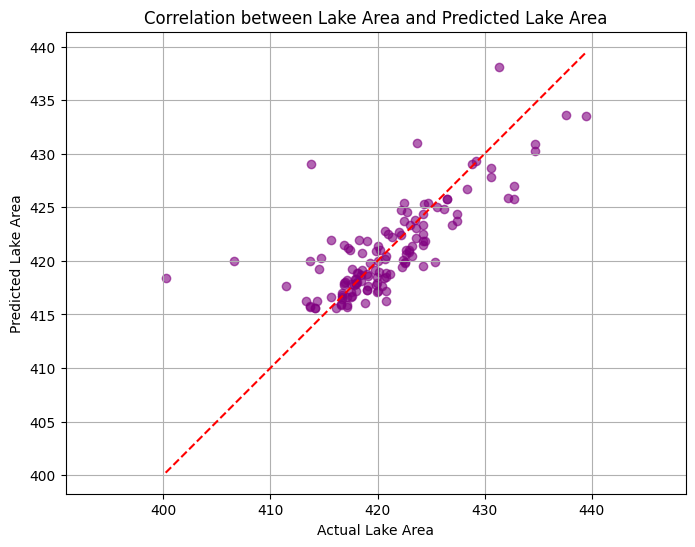

In [43]:
# Correlation plot between Lake_Area and Predicted_Lake_Area
plt.figure(figsize=(8, 6))
plt.scatter(merged_data['Lake_Area'], merged_data['Predicted_Lake_Area'], color='purple', alpha=0.6)
plt.plot([merged_data['Lake_Area'].min(), merged_data['Lake_Area'].max()],
         [merged_data['Lake_Area'].min(), merged_data['Lake_Area'].max()],
         color='red', linestyle='--')  # 45-degree line for reference
plt.title('Correlation between Lake Area and Predicted Lake Area')
plt.xlabel('Actual Lake Area')
plt.ylabel('Predicted Lake Area')
plt.grid()
plt.axis('equal')  # Equal scaling
plt.savefig('results/corr_awi.png', bbox_inches='tight')  
plt.show()  # Display the correlation plot

### Calculate Lake level from Lake area

In this section we will calculate the Lake height above sea level based on previously computed lake areas and the polynomial regression fit function. It is used to fill the data gap in lake level data from the altimetric datasets, especially for the year 2004-2008. the calculated lake height will be saved as csv file in the result folder as Height_Cal_awi.csv

Use the fitted regression coefficients, together with the datum height, to convert every Landsat-derived area observation back into an estimated Relative Lake Level (RLL) — a way of filling gaps in the water-level record wherever only a satellite image (no altimetry) is available.

**Key functions:** `calculate_rll_from_area()`.

In [44]:
# Define the coefficients from the regression equation
a = coefficient_quadratic  # Quadratic coefficient
b = coefficient_linear      # Linear coefficient
c = intercept               # Intercept

datum = datum_height # the reference height we used in regression fitting

file_path = 'results/Area_awi_3dd.csv' # the area calculated from MNDWI
# Calculate lake level from the lake area data
calculate_rll = calculate_rll_from_area(file_path, a, b, c, datum)

# The calculated Rll DataFrame contains the 'Date' and 'Height_cal' columns
print(calculate_rll)

                          Date   Height_cal
0   1992-02-23 07:04:34.652081  1636.927115
4   1992-10-20 07:01:51.388000  1638.087104
5   1992-11-21 07:01:22.533013  1637.416442
6   1992-12-07 07:01:37.538088  1637.154377
11  1993-11-24 07:02:18.196019  1637.169851
..                         ...          ...
251 2024-07-08 07:39:45.949266  1638.287091
252 2024-11-13 07:40:22.614074  1638.872871
253 2024-11-29 07:40:35.597230  1638.313177
254 2024-12-15 07:40:24.224371  1638.587028
255 2024-12-31 07:40:26.942590  1638.448947

[210 rows x 2 columns]


### Combine the Altimetric recorded Height and Calculated Height

In this section the original lake level data from altimetric satelite products, Alt_Height_COMB.csv, and the calculated lake level data in the above section,Height_Cal_awi.csv, is to be merged to get one Lake level data. the merged data will be saved in the result folder named as Lake_Height_Ext_awi.csv. this data will be used in the next section to derive the lake level, area and volume variation.

Merge the original altimetric water-level record with the newly calculated (image-derived) water levels into one continuous, extended lake-height dataset, filling gaps such as the 2004 data gap in the altimetric record.

**Key functions:** `merge_and_process_height_data()`.

In [45]:
# Define paths to your data files
file_path_alt = 'Alt_Height_COMB.csv'
file_path_cal = 'results/Height_Cal_awi.csv'

# Merge and process height data
final_dataset = merge_and_process_height_data(file_path_alt, file_path_cal)

# Display the final merged dataset
print("\nFinal Merged Dataset:")
print(final_dataset)


Final Merged Dataset:
                           Date       Height
0    1992-02-23 07:04:34.652081  1636.927115
1    1992-09-26 00:00:00.000000  1638.040000
2    1992-10-16 00:00:00.000000  1638.310000
3    1992-10-20 07:01:51.388000  1638.087104
4    1992-11-05 00:00:00.000000  1637.740000
...                         ...          ...
1025 2024-10-29 00:00:00.000000  1638.645000
1026 2024-11-13 07:40:22.614074  1638.872871
1027 2024-11-29 07:40:35.597230  1638.313177
1028 2024-12-15 07:40:24.224371  1638.587028
1029 2024-12-31 07:40:26.942590  1638.448947

[1030 rows x 2 columns]


# Lake Volume Variation Calculation 

Based on the second order polynomial regression investigated in the preceding graph, which compares Relative lake Level (RLL) to lake Surface Area (LSA). 
Based on the second order polynomial regression investigated in the previous graph, the lake Level (RLL) versus the lake Area (LSA) is equated as 

    LSA=  a*RLL^2 + b*RLL + c.................................(1)

By integrating equation (1) with the Reference lake level (L), we can calculate the lake volume Variation (LVV) as shown in equation (2). 

    LVV = (a/3)*l^3 + (b/2)*l^2+ c*L..............................(2)

where, the units for RLL, LSA and LVVV are m, km2 and 10^6 m3(Mm3), respectively.


#### Loading and Preparing Lake Height Data:
This cell is responsible for loading the lake height data from a CSV file and preparing it for analysis. It ensures the 'Date' column is in the correct datetime format, defines the datum level, and calculates the Relative Lake Level (RLL) by subtracting the datum level from the lake height. This preparation step is crucial for subsequent calculations.

Load the final, extended lake-height dataset and compute the Relative Lake Level (RLL) for every record by subtracting the datum height, the variable that anchors the Area–Volume–Elevation relationship you will use next.

**Key functions:** `pandas.read_csv()`, `pandas.to_datetime()`.

In [46]:
# Read or Load the final modified (extended) lake height data, 
# the leke height data recoeded from altimetric satelites and height calculated from lake area derived from landsat
Lake_Level = pd.read_csv('results/Lake_Height_Ext_awi.csv')

# Ensure the 'Date' column is in datetime format
Lake_Level['Date'] = pd.to_datetime(Lake_Level['Date'])

# Define the datum level (in m.a.s.l.)
datum_level = datum_height  # Assume datum_height is defined elsewhere
datum_date = pd.to_datetime(datum_date)  # Ensure datum_date is in datetime format

# Create a column for Relative Lake Level (RLL)
Lake_Level['RLL'] = Lake_Level['Height'] - datum_level  # RLL in meters

#### Calculating Lake Surface Area and Volume Variation:
This cell calculates the Lake Surface Area (LSA) and Lake Volume Variation (LVV) based on the Relative Lake Level (RLL) using a second-order polynomial regression model. It reshapes the RLL data for compatibility with the regression calculations, retrieves the necessary coefficients, and applies the polynomial formulas to compute both LSA and LVV. These calculations are essential for understanding the relationship between lake level and its area and volume variations.

Apply the polynomial regression coefficients to calculate Lake Surface Area (LSA) and Lake Volume Variation (LVV) directly from RLL — LVV is obtained by integrating the Area–Depth polynomial, giving you the core output metric of this whole workflow.

**Key functions:** `.values.reshape()`, polynomial arithmetic on pandas Series.

In [47]:
# Prepare RLL for regression
RLL = Lake_Level['RLL'].values.reshape(-1, 1)  # Reshape for sklearn

# Get the coefficients of second order polynomial regression
a = coefficient_quadratic  # Quadratic coefficient
b = coefficient_linear      # Linear coefficient
c = intercept               # Intercept

# Calculate LSA using the polynomial regression formula
Lake_Level['LSA'] = (a * Lake_Level['RLL']**2) + (b * Lake_Level['RLL']) + c

# Calculate Lake Volume Variation (LVV) using the provided formula
Lake_Level['LVV'] = (a * Lake_Level['RLL']**3) / 3 + (b * Lake_Level['RLL']**2) / 2 + c * Lake_Level['RLL']

Export the final table of Date, RLL, LSA, and LVV to CSV, the deliverable dataset that the remaining plotting cells will visualise.

**Key functions:** `.to_csv()`.

In [48]:
# Optionally save the results
Lake_Level.to_csv('results/Lake_Volume_Variation_awi.csv', index=False)

#### Plotting Lake volume variation
This help to visualizes the Lake Volume Variation (LVV) over time..

Plot Lake Volume Variation (LVV) over the full multi-decadal record relative to the chosen datum, the headline chart summarising how Lake Ziway's storage has changed through time.

**Key functions:** `plt.plot()`, `plt.title()`, `plt.savefig()`.

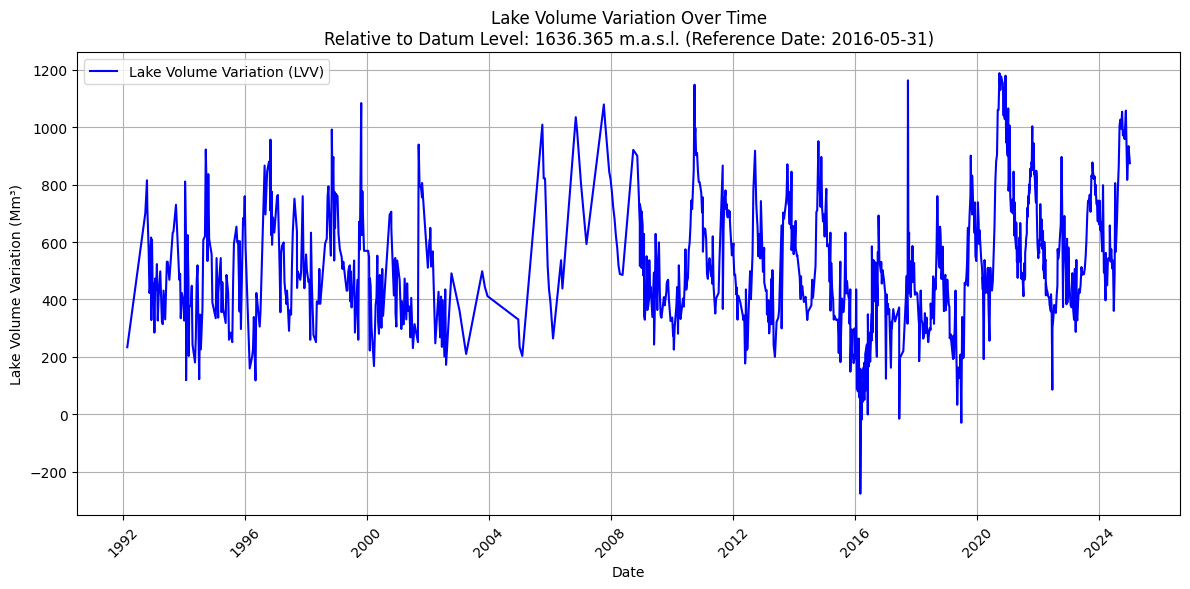

Lake Volume Variation and Surface Area calculated and saved to 'Lake_Volume_Variation.csv'.


In [49]:
# Plotting the Lake Volume Variation (LVV) as a time series
plt.figure(figsize=(12, 6))
plt.plot(Lake_Level['Date'], Lake_Level['LVV'], label='Lake Volume Variation (LVV)', color='blue')
plt.title(f'Lake Volume Variation Over Time\n'
          f'Relative to Datum Level: {datum_level} m.a.s.l. (Reference Date: {datum_date.strftime("%Y-%m-%d")})')
plt.xlabel('Date')
plt.ylabel('Lake Volume Variation (Mm³)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.grid()
plt.savefig('results/Lake_Volume_Variation_awi.png',bbox_inches='tight')  # Save the plot as an image
plt.show()

print("Lake Volume Variation and Surface Area calculated and saved to 'Lake_Volume_Variation.csv'.")

## Plot Lake Surface Area, and Volume Variation together
This code cell creates a dual-axis plot to visualize both Lake Volume Variation (LVV) and Lake Surface Area (LSA) over time.
The purpose is to visually represent the relationship between Lake Volume Variation (LVV) and Lake Surface Area (LSA) over time, utilizing a dual-axis plot for clarity. By plotting LVV on the left y-axis and LSA on the right y-axis, the code allows for direct comparison of these two distinct but related metrics, each having its own scale.

Build a dual-axis chart that overlays Lake Volume Variation and Lake Surface Area on the same time axis but different y-axes, making it easy to see how the two metrics move together.

**Key functions:** `plt.subplots()`, `.twinx()`.

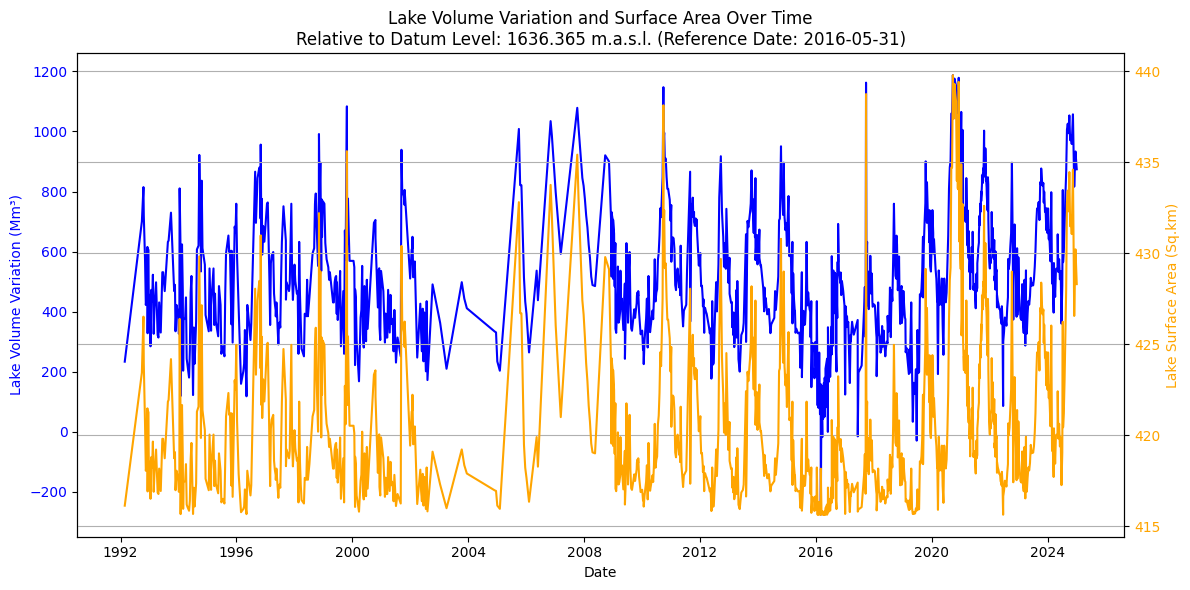

Lake Volume Variation and Surface Area calculated and saved to 'Lake_Volume_Variation_Results.csv'.


In [50]:

# Plotting the Lake Volume Variation (LVV) and Lake Surface Area (LSA) with separate y-axes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot LVV on the left y-axis
ax1.plot(Lake_Level['Date'], Lake_Level['LVV'], label='Lake Volume Variation (LVV)', color='blue')
ax1.set_xlabel('Date')
ax1.set_ylabel('Lake Volume Variation (Mm³)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a second y-axis for LSA
ax2 = ax1.twinx()
ax2.plot(Lake_Level['Date'], Lake_Level['LSA'], label='Lake Surface Area (LSA)', color='orange')
ax2.set_ylabel('Lake Surface Area (Sq.km)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

# Title and grid
plt.title(f'Lake Volume Variation and Surface Area Over Time\n'
          f'Relative to Datum Level: {datum_level} m.a.s.l. (Reference Date: {datum_date.strftime("%Y-%m-%d")})')
fig.tight_layout()  # Adjust layout to prevent clipping
plt.grid()
plt.savefig('results/LSA_LVV_awi.png')  # Save the plot as an image
plt.show()

print("Lake Volume Variation and Surface Area calculated and saved to 'Lake_Volume_Variation_Results.csv'.")

## Time-series plots of RLL,LSA, and LVV
The code cell below creates a series of three separate plots that visualize the Relative Lake Level (RLL), Lake Surface Area (LSA), and Lake Volume Variation (LVV) over time. Each metric is displayed in its own subplot, allowing for clear comparisons of their trends without clutter. The code includes appropriate labels for each y-axis and a common x-axis label for better readability.

Generate a stacked, three-panel figure showing Relative Lake Level, Lake Surface Area, and Lake Volume Variation as separate but aligned time series, useful for comparing the shape and timing of each metric.

**Key functions:** `plt.subplots()`, dictionary-driven loop over metrics, `.legend()`.

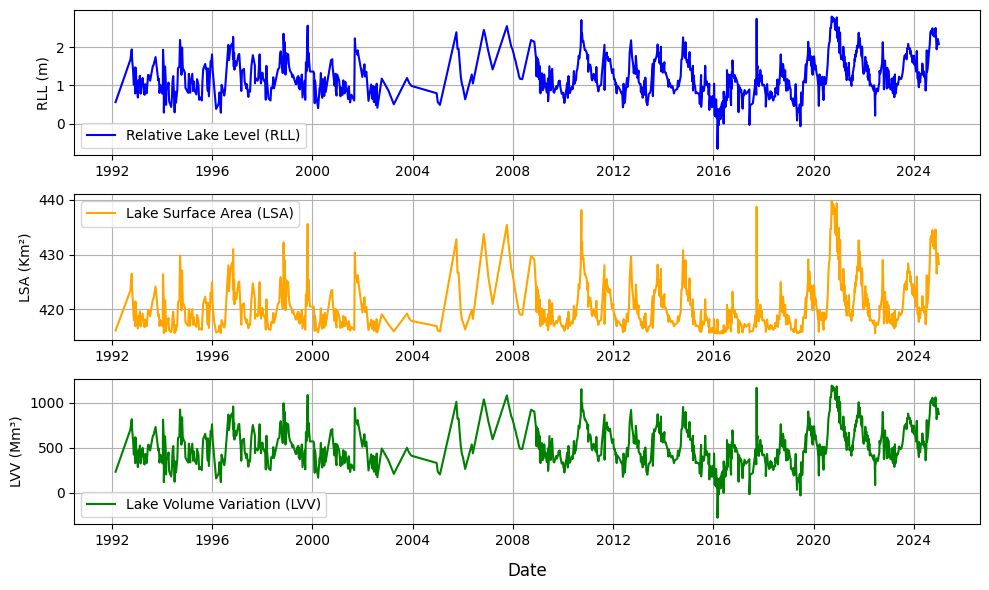

In [51]:
# Create subplots for RLL, LSA, and LVV
fig, axs = plt.subplots(3, 1, figsize=(10, 6))

# Define metrics and their properties
metrics = {
    'RLL': {'data': Lake_Level['RLL'], 'label': 'Relative Lake Level (RLL)', 'color': 'blue', 'unit': 'm'},
    'LSA': {'data': Lake_Level['LSA'], 'label': 'Lake Surface Area (LSA)', 'color': 'orange', 'unit': 'Km²'},
    'LVV': {'data': Lake_Level['LVV'], 'label': 'Lake Volume Variation (LVV)', 'color': 'green', 'unit': 'Mm³'}
}

# Loop through each metric to create plots
for ax, (metric, props) in zip(axs, metrics.items()):
    ax.plot(Lake_Level['Date'], props['data'], label=props['label'], color=props['color'])
    ax.set_ylabel(f"{metric} ({props['unit']})")
    ax.grid()
    ax.legend()

# Common x-axis label
plt.xlabel('Date', fontsize=12, labelpad=10)

# Adjust layout and save
plt.tight_layout()
plt.savefig('results/RLL_LSA_LVV_awi.png')
plt.show()

## Time-Series plots of RLL, LSA, and LVV with Threshold Indicators

This code cell presents the time-series plots of Relative Lake Level (RLL), Lake Surface Area (LSA), and Lake Volume Variation (LVV), incorporating horizontal threshold lines for reference. This enhances the analysis by illustrating how each metric measures against its respective threshold while maintaining clarity with appropriate y-axis labels and a common x-axis label.

Extend the three-panel time-series plot with horizontal threshold lines for each metric, helping trainees quickly identify periods when RLL, LSA, or LVV dropped below (or exceeded) a management-relevant reference level.

**Key functions:** `plt.subplots()`, `.axhline()`.

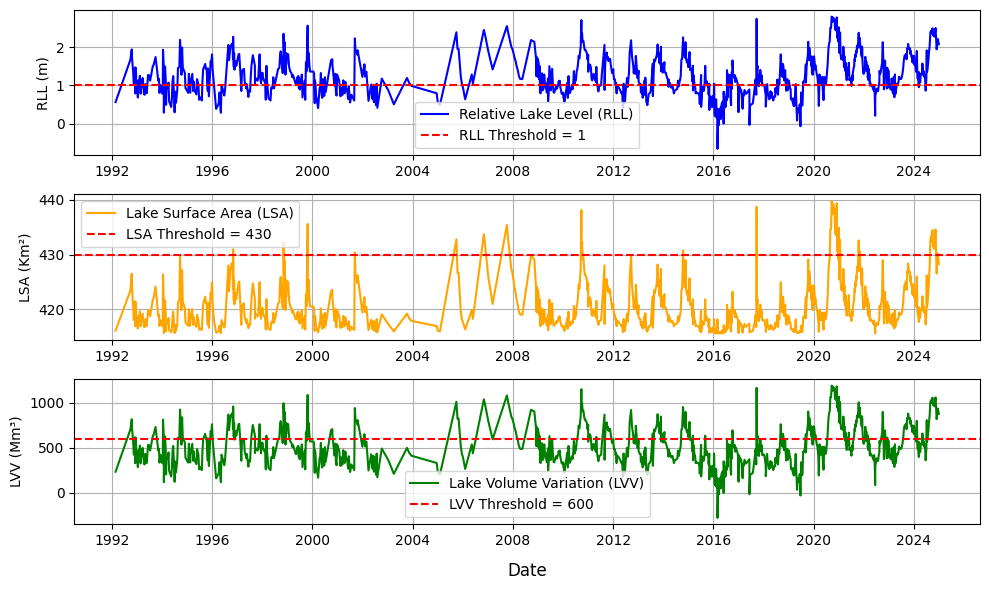

In [52]:
# Clear thresholds for each metric
thresholds = {
    'RLL': (1, 'Relative Lake Level (RLL)', 'blue'),
    'LSA': (430, 'Lake Surface Area (LSA)', 'orange'),
    'LVV': (600, 'Lake Volume Variation (LVV)', 'green')
}

# Create subplots
fig, axs = plt.subplots(3, 1, figsize=(10, 6))

# Create a list to easily manage plots
for i, (key, (threshold, label, color)) in enumerate(thresholds.items()):
    axs[i].plot(Lake_Level['Date'], Lake_Level[key], label=label, color=color)
    axs[i].axhline(threshold, color='red', linestyle='--', label=f'{key} Threshold = {threshold}')
    axs[i].set_ylabel(f'{key} ({"m" if key == "RLL" else "Km²" if key == "LSA" else "Mm³"})')
    axs[i].grid()
    axs[i].legend()

# Set common x-label
plt.xlabel('Date', fontsize=12, labelpad=10)

# Adjust layout and save figure
plt.tight_layout()
plt.savefig('results/RLL_LSA_LVV_1_trline.png')
plt.show()

### Annual Time-Series Analysis of RLL, LSA, and LVV with Year Selection
This code enables a focused analysis of the Relative Lake Level (RLL), Lake Surface Area (LSA), and Lake Volume Variation (LVV) for user-defined years or year ranges. Each plot displays monthly data for the selected year(s) alongside horizontal threshold lines for reference, facilitating clear comparisons of lake metrics. The output plots are saved as PNG files (example name for 2020 is Lake_Analysis_2020.png ), ensuring ease of access for further evaluation and reporting.

Build an interactive, year-filtered view of RLL, LSA, and LVV, letting a trainee type in a single year or a year range and immediately see the corresponding annual plots with threshold indicators — useful for focused, year-by-year reporting.

**Key functions:** `.dt.year`, `.dt.month`, `input()`, `plot_Annual()`.

In [59]:
# Set thresholds
thresholds = {
    'RLL': 1.0,
    'LSA': 430,
    'LVV': 600
}

# Ensure the Date column is in datetime format and extract Year and Month
Lake_Level['Date'] = pd.to_datetime(Lake_Level['Date'])
Lake_Level['Year'] = Lake_Level['Date'].dt.year
Lake_Level['Month'] = Lake_Level['Date'].dt.month

# Get unique years and user input for the year or range of years
unique_years = Lake_Level['Year'].unique()
year_input = input(f"Available years: {unique_years}\nEnter a single year or a range (e.g., 2015-2020): ")

# Parse the input
if '-' in year_input:
    start_year, end_year = map(int, year_input.split('-'))
    selected_years = [year for year in unique_years if start_year <= year <= end_year]
else:
    selected_years = [int(year_input)] if int(year_input) in unique_years else []

# # Generate plots for the selected years
# for year in selected_years:
#     plot_Annual(year, Lake_Level[Lake_Level['Year'] == year])

# print("Annual plots for selected years saved.")

Available years: [1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005
 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019
 2020 2021 2022 2023 2024]
Enter a single year or a range (e.g., 2015-2020):  1992-2000


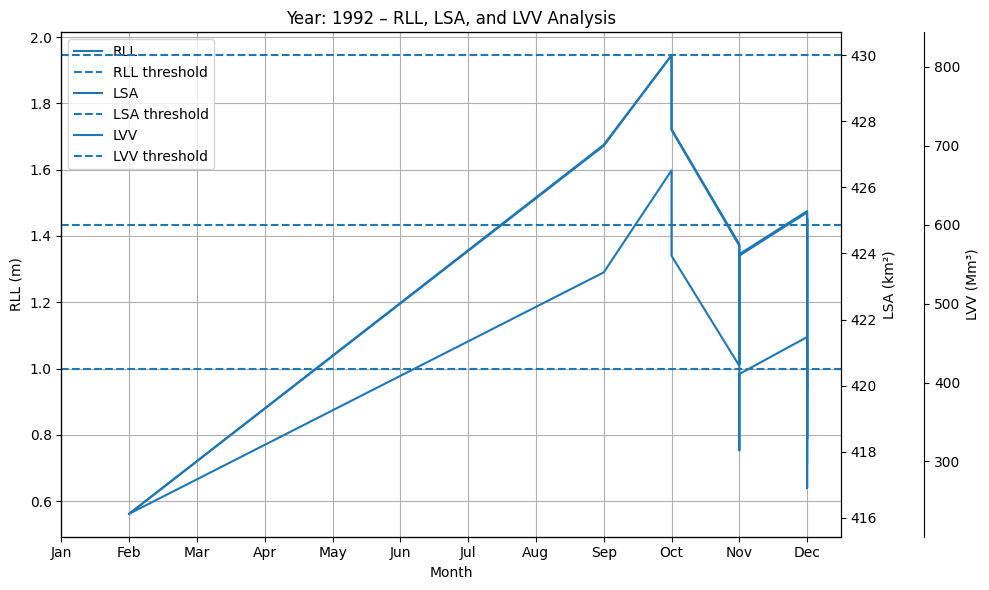

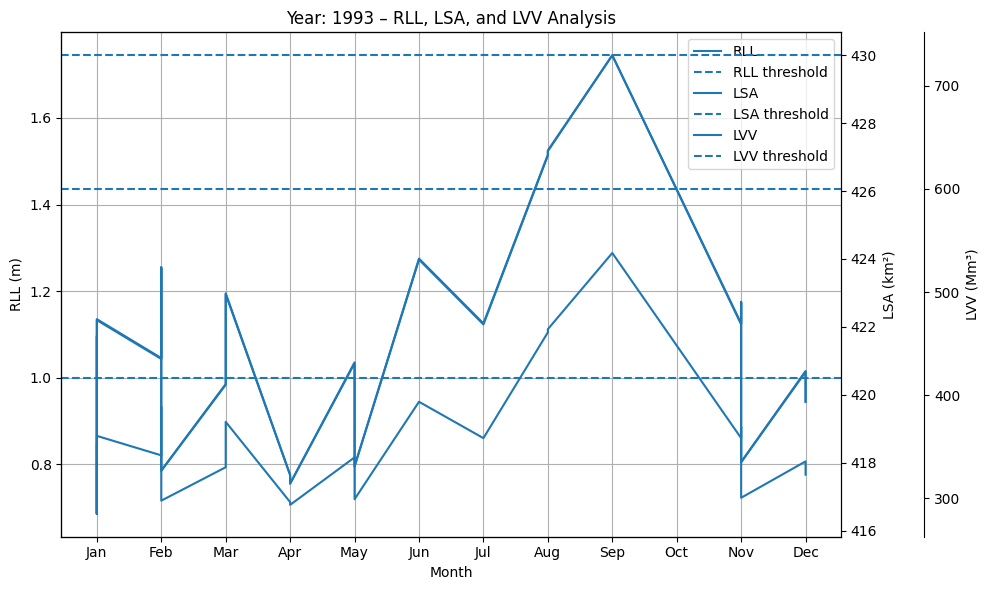

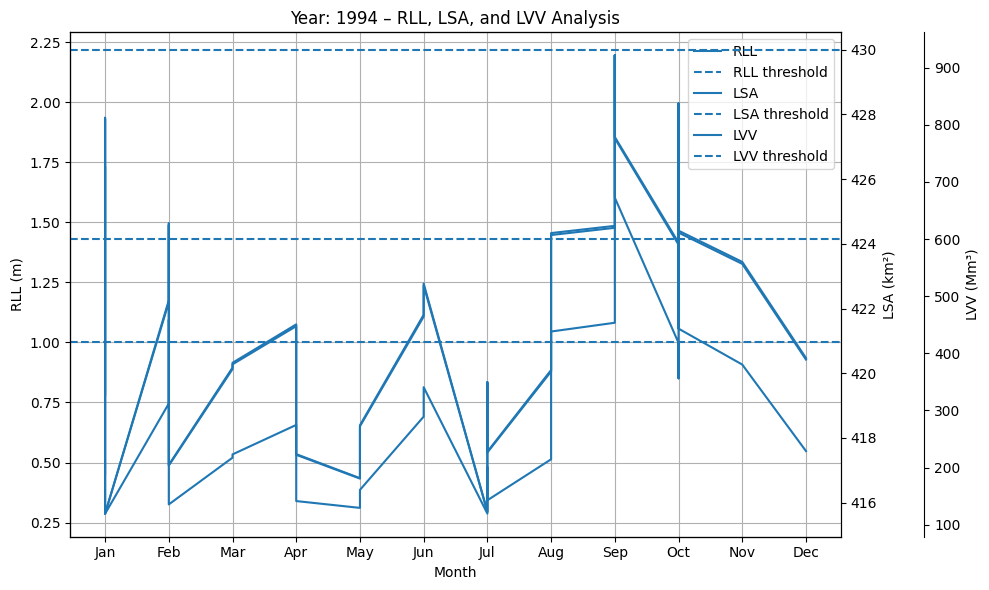

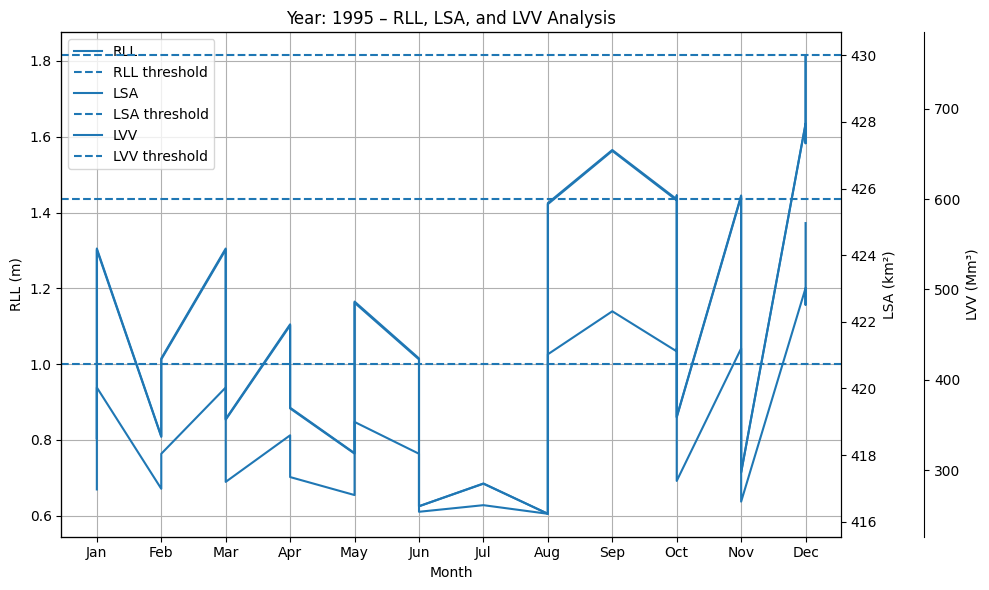

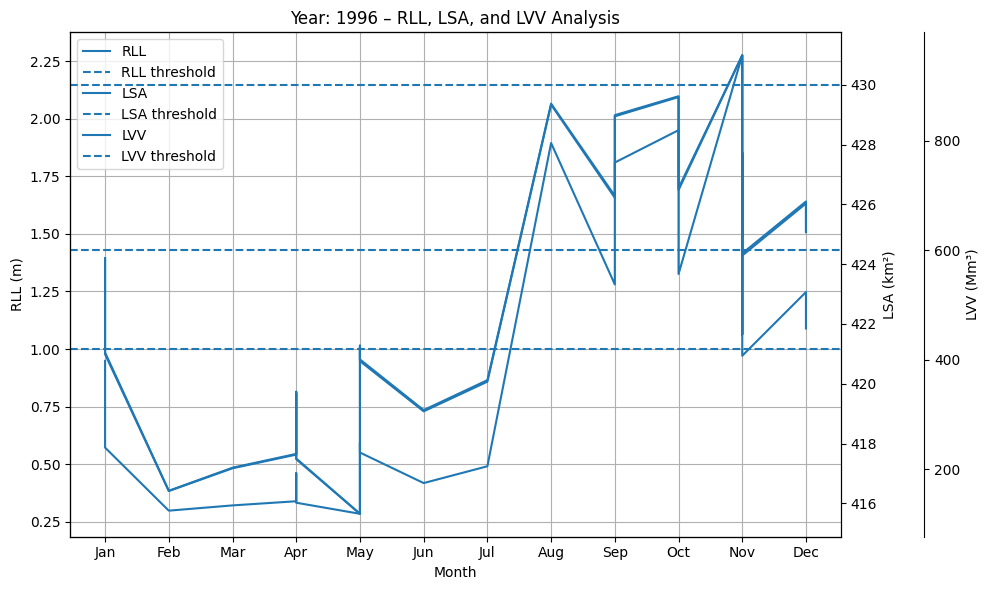

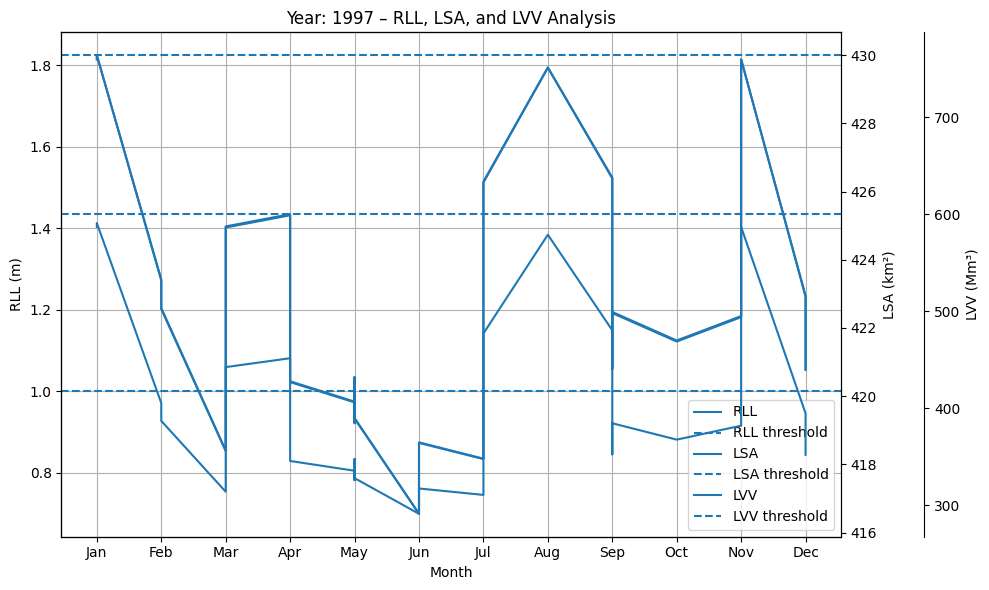

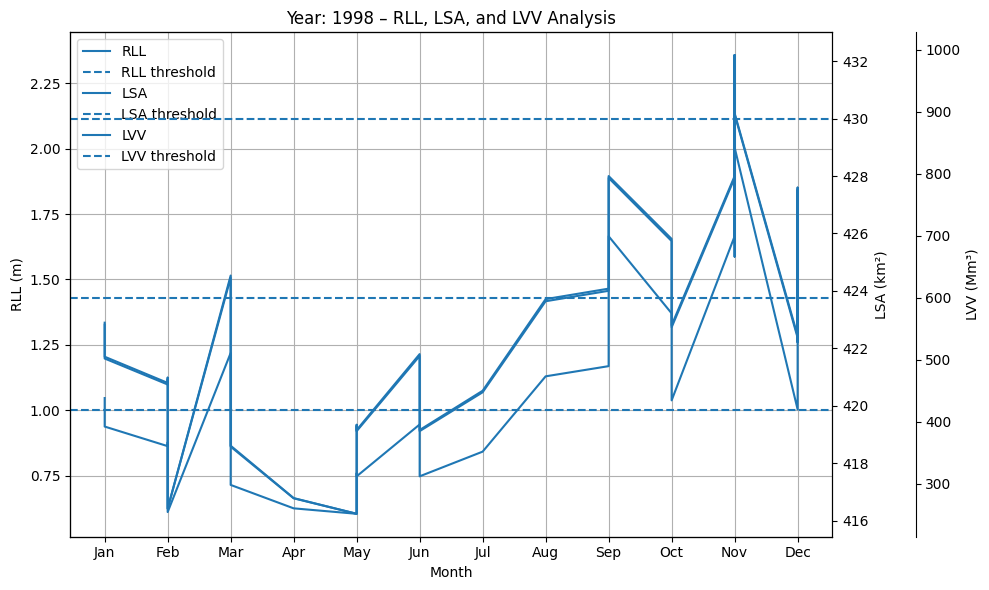

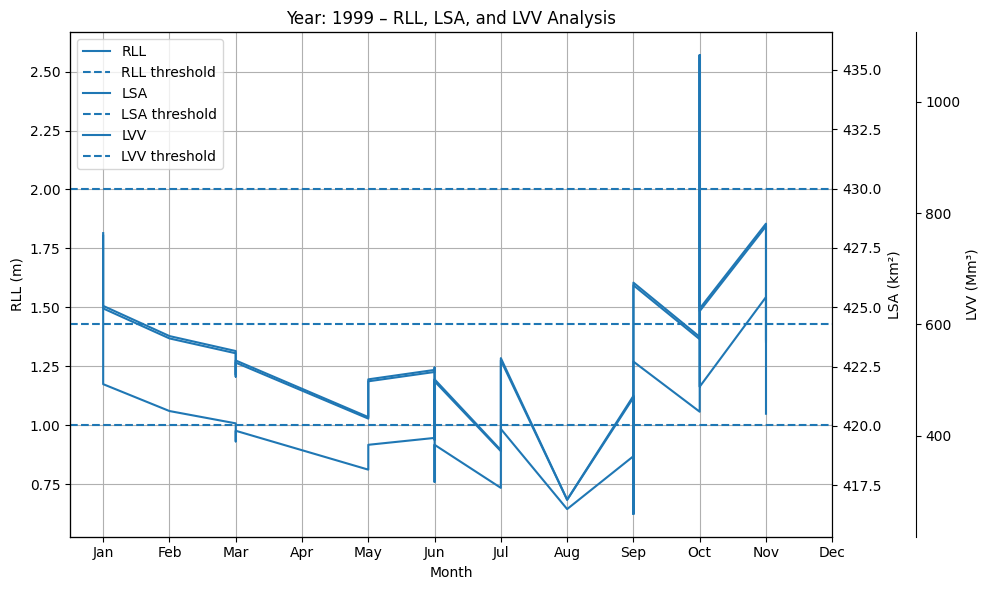

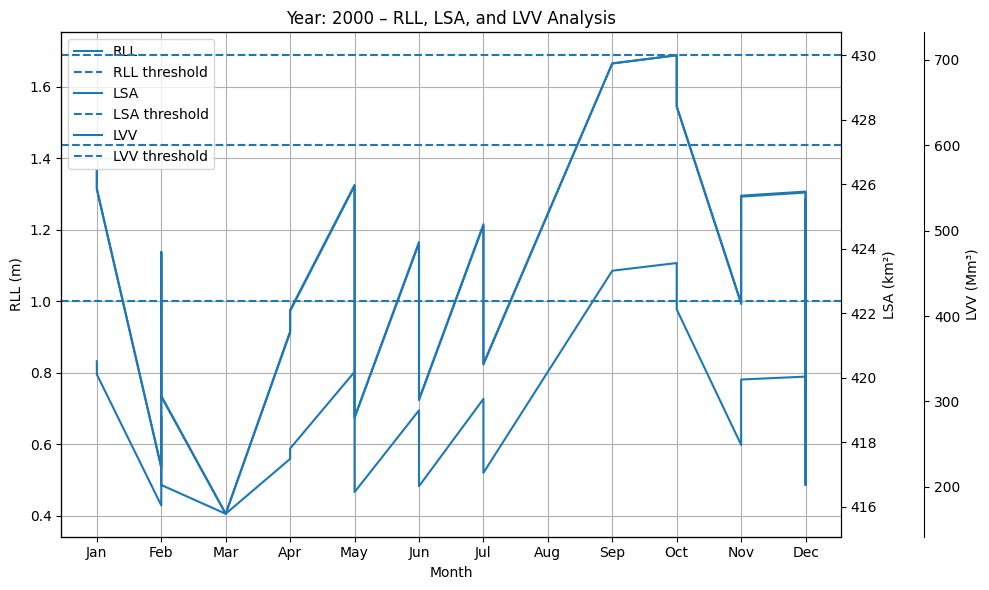

In [60]:
for year in selected_years:
    annual_data = Lake_Level.loc[
        Lake_Level["Year"] == year
    ]

    plot_annual_lake_metrics(
        year=year,
        data=annual_data,
        thresholds=thresholds,
        output_dir="results",
        show=True,
    )